In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime

In [48]:
# Use pd.read_csv() (or the appropriate Pandas reader) to bring your file into a DataFrame.
csv_file = pd.read_csv("../Data/Louisville_Metro_KY_Firearms_Intake_Normalized.csv")
df = csv_file

In [4]:
df.head()

,INCIDENT_NUMBER,UCR_CATEGORY,TYPE_OF_FIREARM,FIREARM_MANUFACTURER,FIREARM_MODEL,FIREARM_CALIBER,RECOVERY_DATE,ADDRESS_GEOCODE_TYPE,RECOVERY__ADDRESS,CITY,...,RECOVERY_ZIPCODE,PERSON_RECOVERED_FROM_RACE,PERSON_RECOVERED_FROM_SEX,PERSON_RECOVERED_FROM_AGE,Address_Concat,Longitude,Latitude,Confidence,Source,ObjectId
0,80-10-011494,Wpns Law Violation,"Pistol, Semi-automatic",Manurin S.A.,NaN,765M,2010-02-17T00:00:00Z,BLOCK,9400 National Tpke,Louisville,...,40118.0,White,M,44.0,9400 National Tpke Louisville KY 40118,-85.752898,38.125321,0.54,openaddresses,1
1,80-10-011506,Narcotics,"Shotgun, Pump Action",Remington Arms,Shotgun: Model,20GA,2010-02-17T00:00:00Z,BLOCK,4500 Landside Dr,Louisville,...,40220.0,Black,M,19.0,4500 Landside Dr Louisville KY 40220,-85.620998,38.198673,1.00,openaddresses,2
2,80-10-011506,Narcotics,"Shotgun, Pump Action",Remington Arms,Shotgun: Model,20GA,2010-02-17T00:00:00Z,BLOCK,4500 Landside Dr,Louisville,...,40220.0,Black,M,19.0,4500 Landside Dr Louisville KY 40220,-85.620998,38.198673,1.00,openaddresses,3
3,80-10-011506,Narcotics,"Shotgun, Pump Action",Remington Arms,Shotgun: Model,20GA,2010-02-17T00:00:00Z,BLOCK,4500 Landside Dr,Louisville,...,40220.0,Black,M,19.0,4500 Landside Dr Louisville KY 40220,-85.620998,38.198673,1.00,openaddresses,4
4,80-10-011506,Narcotics,"Shotgun, Pump Action",Remington Arms,Shotgun: Model,20GA,2010-02-17T00:00:00Z,BLOCK,4500 Landside Dr,Louisville,...,40220.0,Black,M,19.0,4500 Landside Dr Louisville KY 40220,-85.620998,38.198673,1.00,openaddresses,5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11742 entries, 0 to 11741
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   INCIDENT_NUMBER             11742 non-null  object 
 1   UCR_CATEGORY                11741 non-null  object 
 2   TYPE_OF_FIREARM             11742 non-null  object 
 3   FIREARM_MANUFACTURER        10224 non-null  object 
 4   FIREARM_MODEL               6847 non-null   object 
 5   FIREARM_CALIBER             9574 non-null   object 
 6   RECOVERY_DATE               10872 non-null  object 
 7   ADDRESS_GEOCODE_TYPE        11742 non-null  object 
 8   RECOVERY__ADDRESS           11742 non-null  object 
 9   CITY                        11729 non-null  object 
 10  state                       11740 non-null  object 
 11  RECOVERY_ZIPCODE            11571 non-null  float64
 12  PERSON_RECOVERED_FROM_RACE  11742 non-null  object 
 13  PERSON_RECOVERED_FROM_SEX   929

The best candidate for a key to link different datasets is the "INCIDENT_NUMBER" column, which is included in all LMPD datasets.

The "FIREARM_MODEL" column has many null values. The "FIREARM_CALIBER", "PERSON_RECOVERED_FROM_SEX", and "PERSON_RECOVERED_FROM_AGE" columns also have less than 10,000 nun-null  values out of 11742 total rows. Something will need to be done about them.

The vast majority of column values are of the "object" data type. Changing them to the more descriptive "category" data type is a good first step, as these columns contain entries that have no continuity or relation to one another, apart from belonging to the same category.

In [ ]:
df["INCIDENT_NUMBER"] = new_df["INCIDENT_NUMBER"].astype("category")
df["UCR_CATEGORY"] = df["UCR_CATEGORY"].astype("category")
df["TYPE_OF_FIREARM"] = df["TYPE_OF_FIREARM"].astype("category")
df["FIREARM_MANUFACTURER"] = df["FIREARM_MANUFACTURER"].astype("category")
df["FIREARM_MODEL"] = df["FIREARM_MODEL"].astype("category")
df["FIREARM_CALIBER"] = df["FIREARM_CALIBER"].astype("category")
df["CITY"] = df["CITY"].astype("category")
df["state"] = df["state"].astype("category")
df["PERSON_RECOVERED_FROM_RACE"] = df["PERSON_RECOVERED_FROM_RACE"].astype("category")
df["PERSON_RECOVERED_FROM_SEX"] = df["PERSON_RECOVERED_FROM_SEX"].astype("category")


# The below columns are found only in the "normalized" version of the CSV. Comment out if you wish to run the raw CSV instead.
# This is purely for personal curiosity. The normalized version is far more common, and the intended default dataset.

df["ADDRESS_GEOCODE_TYPE"] = df["ADDRESS_GEOCODE_TYPE"].astype("category")
df["RECOVERY__ADDRESS"] = df["RECOVERY__ADDRESS"].astype("category")
df["Address_Concat"] = df["Address_Concat"].astype("category")
df["Source"] = df["Source"].astype("category")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11742 entries, 0 to 11741
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   INCIDENT_NUMBER             11742 non-null  category
 1   UCR_CATEGORY                11741 non-null  category
 2   TYPE_OF_FIREARM             11742 non-null  category
 3   FIREARM_MANUFACTURER        10224 non-null  category
 4   FIREARM_MODEL               6847 non-null   category
 5   FIREARM_CALIBER             9574 non-null   category
 6   RECOVERY_DATE               10872 non-null  object  
 7   ADDRESS_GEOCODE_TYPE        11742 non-null  category
 8   RECOVERY__ADDRESS           11742 non-null  category
 9   CITY                        11729 non-null  category
 10  state                       11740 non-null  category
 11  RECOVERY_ZIPCODE            11571 non-null  float64 
 12  PERSON_RECOVERED_FROM_RACE  11742 non-null  category
 13  PERSON_RECOVERED

In [ ]:
# Columns found only in the raw CSV. Uncomment this code only if you wish to run the raw CSV, and have commented out the columns above as instructed.

# df["RECOVERY_DATE"] = df["RECOVERY_DATE"].astype("category")
# df["RECOVERY_BLOCK_ADDRESS"] = df["RECOVERY_BLOCK_ADDRESS"].astype("category")
# df["year"] = df["year"].astype("category")

# df.info()

In [8]:
df.shape

(11742, 21)

The .value_counts() function returns nothing of value, except to show every row is unique. It will be necessary to run it individually on every column of interest.

In [ ]:
df.value_counts()

INCIDENT_NUMBER  UCR_CATEGORY        TYPE_OF_FIREARM         FIREARM_MANUFACTURER   FIREARM_MODEL    FIREARM_CALIBER  RECOVERY_DATE         ADDRESS_GEOCODE_TYPE  RECOVERY__ADDRESS     CITY        state  RECOVERY_ZIPCODE  PERSON_RECOVERED_FROM_RACE  PERSON_RECOVERED_FROM_SEX  PERSON_RECOVERED_FROM_AGE  Address_Concat                            Longitude   Latitude   Confidence  Source         ObjectId
80-08-008343     Burglary            Pistol, Semi-automatic  Jennings Firear        Jennings Firear  380C             2010-01-20T00:00:00Z  BLOCK                 3400 Shagbark Rd      Louisville  KY     40216.0           Black                       M                          30.0                       3400 Shagbark Rd Louisville KY 40216      -85.843407  38.196532  1.00        openaddresses  8750        1
80-08-091695     Theft Fr Veh        Pistol, Semi-automatic  Fie                    E28              25C              2008-11-29T00:00:00Z  BLOCK                 1000 Cladwell         Lou

The "RECOVERY_DATE" column is in a date-time-utc format, but no meaningful hours/minutes/seconds data is present. For this reason, the column will be modified to a simpler date format. The chart shows something remarkable occurred on 2013-06-20, when 135 firearms were recovered on a single day.

count    2230.000000
mean        4.875336
std         5.714822
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
max       135.000000
Name: count, dtype: float64
RECOVERY_DATE
2013-06-20    135
2016-12-14     60
2014-06-20     54
2013-10-23     53
2017-01-24     46
             ... 
2010-01-30      1
2010-01-24      1
2010-01-22      1
2016-07-16      1
2014-05-10      1
Name: count, Length: 2230, dtype: int64


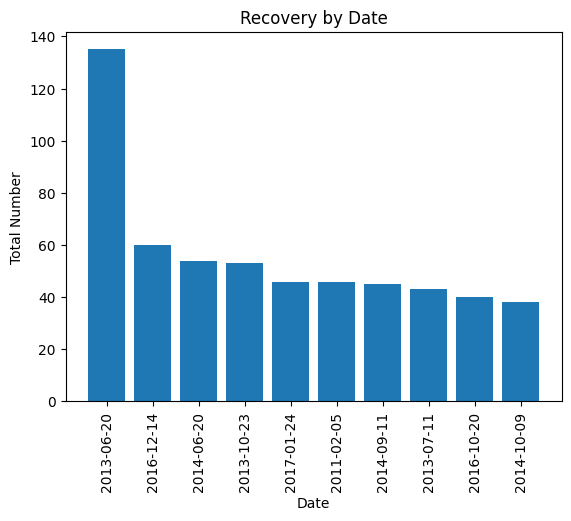

In [38]:
df["RECOVERY_DATE"] = pd.to_datetime(df["RECOVERY_DATE"], utc=True, errors='coerce').dt.date

recovery_date = df["RECOVERY_DATE"].value_counts().head(10)
print(df["RECOVERY_DATE"].value_counts().describe())
print(df["RECOVERY_DATE"].value_counts())

plt.bar(recovery_date.index.astype(str), recovery_date.values)
plt.title("Recovery by Date")
plt.xlabel("Date")
plt.xticks(rotation=90)
plt.ylabel("Total Number")
plt.show()

count    2230.000000
mean        4.875336
std         5.714822
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
max       135.000000
Name: count, dtype: float64
RECOVERY_DATE
2013-06-20    135
2016-12-14     60
2014-06-20     54
2013-10-23     53
2017-01-24     46
             ... 
2010-01-30      1
2010-01-24      1
2010-01-22      1
2016-07-16      1
2014-05-10      1
Name: count, Length: 2230, dtype: int64


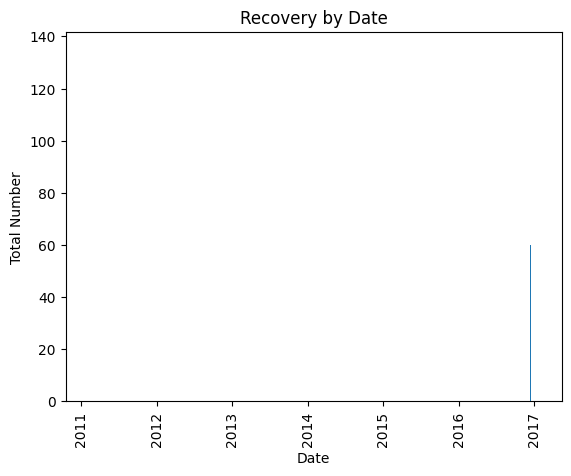

In [40]:
print(df["RECOVERY_DATE"].value_counts().describe())
print(df["RECOVERY_DATE"].value_counts())

recovery_date = df.groupby("RECOVERY_DATE")["RECOVERY_DATE"].value_counts().sort_values(ascending=False).head(10)
plt.bar(recovery_date.index, recovery_date.values)
plt.title("Recovery by Date")
plt.xlabel("Date")
plt.xticks(rotation=90)
plt.ylabel("Total Number")
plt.show()

Still, out of a dataset spanning more than 6 years with 11742 entries, 135 rows is a small selection of data. Zooming out to months and/or years is necessary for further EDA.

In [ ]:
# Using a test dataframe while writing code before applying to the original.
df_year = df[["RECOVERY_DATE"]].copy()

df_year.info()
print(df_year["RECOVERY_DATE"].value_counts().describe())
print(df_year["RECOVERY_DATE"].value_counts())


# Somehow, I need to extract the year, (then the month as a stretch goal.)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11742 entries, 0 to 11741
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   RECOVERY_DATE  10872 non-null  object
dtypes: object(1)
memory usage: 91.9+ KB
count    2230.000000
mean        4.875336
std         5.714822
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
max       135.000000
Name: count, dtype: float64
RECOVERY_DATE
2013-06-20    135
2016-12-14     60
2014-06-20     54
2013-10-23     53
2017-01-24     46
             ... 
2010-01-30      1
2010-01-24      1
2010-01-22      1
2016-07-16      1
2014-05-10      1
Name: count, Length: 2230, dtype: int64


In [278]:
print(df.duplicated(subset = ["INCIDENT_NUMBER"]))


# How many incidents resulted in the recovery of just 1 firearm?
# How many resulted in the revovery of 2 or more? 

# Use .duplicated() for this
# Assign count of INCIDENT_NUMBER where .duplicated() returns False to a variable
# Assign count of INCIDENT_NUMBER grouped by INCIDENT_NUMBER where .duplicated() returns True to another variable
# Plot the counts to a pie chart

def null_results():
    i=0
    for incident in df["INCIDENT_NUMBER"]:
        i+=1
    print(i)


def unique_duplicated_values_count(column_name):
    i=0
    for value in df[column_name]:
        if value.value_counts() > 1:
            i+=1
    return f"There are {i} unique duplicated values"

print(f"There are {df["INCIDENT_NUMBER"].value_counts()} values.")

0        False
1        False
2        False
3        False
4        False
         ...  
11737    False
11738    False
11739    False
11740    False
11741     True
Length: 11742, dtype: bool
There are INCIDENT_NUMBER
80-13-045271    116
80-14-045134     60
80-16-101135     56
80-16-106571     54
80-13-081413     50
               ... 
80-11-090783      0
80-11-090537      0
80-11-090217      0
80-11-090205      0
80-11-089996      0
Name: count, Length: 8322, dtype: int64 values.


The df.describe() function returns some useful insights. We get maximum and minimum "Latitude" and "Longitude" values where firearms were recovered, as well as 1st quartile, median, and 3rd quartile coordinates, which could potentially be used to draw the general area in which firearms are likely to be recovered, with 25%, 50%, and 75% confidence.

Unfortunately, the idea doesn't stand up to basic scrutiny. A minimum Latitude of 0 suggests a firearm was recovered by LMPD at the equator, which is obviously wrong, and indicates some cleanup of these columns would be necessary to make the idea work. Any value outside the city limits cannot be accepted as legitimate, and would need to be dropped.


The "PERSON_RECOVERED_FROM_AGE" column also offers some insight. We see that despite a maximim recorded age of 87, the vast majority of recoveries are from individuals who are much younger, with 50% from age 28 or less, and 75% from age 38 or less.

In [13]:
df.describe()

,RECOVERY_ZIPCODE,PERSON_RECOVERED_FROM_AGE,Longitude,Latitude,Confidence,ObjectId
count,11571.000000,9017.000000,11741.000000,11741.000000,11741.000000,11742.000000
mean,40217.221502,31.821227,-79.397017,35.376900,0.810610,5871.500000
std,71.612109,12.861886,22.483703,10.013053,0.291876,3389.767765
min,40023.000000,0.000000,-122.440321,0.000000,0.000000,1.000000
25%,40203.000000,22.000000,-85.788638,38.164615,0.660000,2936.250000
50%,40212.000000,28.000000,-85.761323,38.224759,1.000000,5871.500000
75%,40218.000000,38.000000,-85.682488,38.253961,1.000000,8806.750000
max,47130.000000,87.000000,0.000000,43.199428,1.000000,11742.000000


There are correlations between a few numeric columns. "Latitude" and "Longitude" are closely correlated, as expected, but are also strongly correlated with "Confidence", (more than .75 and less than -.75, (greater than 75% correlation)). I believe the column describes their level of confidence that a row's geo-coordinates are correct, but am not positive.

In [15]:
df.corr(numeric_only=True)

,RECOVERY_ZIPCODE,PERSON_RECOVERED_FROM_AGE,Longitude,Latitude,Confidence,ObjectId
RECOVERY_ZIPCODE,1.000000,0.057661,0.058976,-0.061468,-0.048576,0.026204
PERSON_RECOVERED_FROM_AGE,0.057661,1.000000,-0.012536,-0.001597,0.002150,-0.027343
Longitude,0.058976,-0.012536,1.000000,-0.998177,-0.784693,0.451914
Latitude,-0.061468,-0.001597,-0.998177,1.000000,0.786203,-0.451678
Confidence,-0.048576,0.002150,-0.784693,0.786203,1.000000,-0.368380
ObjectId,0.026204,-0.027343,0.451914,-0.451678,-0.368380,1.000000


Checking for unique values, out of 11742 recovered firearms, there are just 6109 "INCIDENT_NUMBER" values, indicating there are many incidents which result in the recovery of multiple firearms.

In [31]:
df.nunique()

INCIDENT_NUMBER                6109
UCR_CATEGORY                     38
TYPE_OF_FIREARM                  29
FIREARM_MANUFACTURER            459
FIREARM_MODEL                  1142
FIREARM_CALIBER                  58
RECOVERY_DATE                  2230
ADDRESS_GEOCODE_TYPE              2
RECOVERY__ADDRESS              2672
CITY                             55
state                             2
RECOVERY_ZIPCODE                 40
PERSON_RECOVERED_FROM_RACE        9
PERSON_RECOVERED_FROM_SEX         3
PERSON_RECOVERED_FROM_AGE        73
Address_Concat                 2748
Longitude                      2381
Latitude                       2386
Confidence                       67
Source                            2
ObjectId                      11742
dtype: int64

Counting for NULL values, it is observed "FIREARM_MODEL" is the most common missing information with nearly 5000 left unreported. Other specific firearm information also have many NULL entries: over 2000 in "FIREARM_CALIBER" and 1500 in "FIREARM_MANUFACTURER". The precise "RECOVERY_DATE" also seems to have been neglected to be reported nearly 900 times.

Person specific information is also often missing, (nearly 2500 from "PERSON_RECOVERED_FROM_SEX, and 2700 from "PERSON_RECOVERED_FROM_AGE). Notably, "PERSON_RECOVERED_FROM_AGE" has 0 NULL values, which is a bit of a surprise as every single recovered firearm listed is not only taken from a person, but a person whose racial identity is always known. This clearly indicates the creator of the "Normalized" dataset attempted to remove many of the raw version's rows with NULL entries, taking particular interest in the racial identity of those from whom firearms were taken.

In [25]:
df.isnull().sum()

INCIDENT_NUMBER                  0
UCR_CATEGORY                     1
TYPE_OF_FIREARM                  0
FIREARM_MANUFACTURER          1518
FIREARM_MODEL                 4895
FIREARM_CALIBER               2168
RECOVERY_DATE                  870
ADDRESS_GEOCODE_TYPE             0
RECOVERY__ADDRESS                0
CITY                            13
state                            2
RECOVERY_ZIPCODE               171
PERSON_RECOVERED_FROM_RACE       0
PERSON_RECOVERED_FROM_SEX     2452
PERSON_RECOVERED_FROM_AGE     2725
Address_Concat                 870
Longitude                        1
Latitude                         1
Confidence                       1
Source                           1
ObjectId                         0
dtype: int64

At last, it's time to examine each column of interest. "UCR_CATEGORY" describes the reason the firearm was recovered. Of these, "Wpns Law Violation", Narcotics, and Aggravated Assault were the most common by far, ranging from over 3400 to nearly 1900 records.

Notably, Suicide is a far less common reason for firearm recovery at just 419 records. I'd originally thought exploratory data analysis might be skewed by this category, since the type of firearm used in a suicide might seem irrelevant, but the subsequent table seems to indicate that isn't the case.

            counts
count    38.000000
mean    308.973684
std     789.577358
min       1.000000
25%       5.250000
50%      25.000000
75%     129.250000
max    3424.000000
             unique_values  counts
0       Wpns Law Violation    3424
1                Narcotics    3185
2       Aggravated Assault    1864
3                  Robbery     807
4          Stolen Property     493
5                  Suicide     419
6                 Homicide     377
7                 Burglary     254
8           Simple Assault     152
9             Intimidation     136
10             Theft Other     109
11      All Other Offenses      81
12     Accidental Shooting      63
13          Counterfeiting      59
14     Death Investigation      45
15               Vandalism      38
16            Theft Fr Veh      31
17         Family Offenses      27
18         Narcotics Equip      27
19    Justifiable Homicide      23
20             Shoplifting      22
21              Auto Theft      20
22   Injured Person Repo

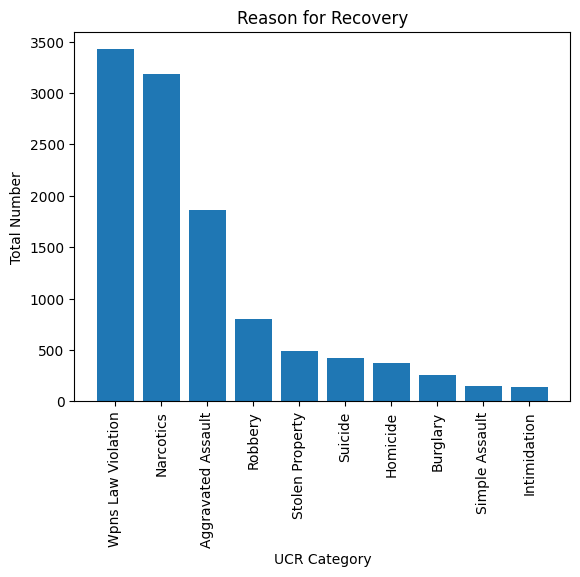

In [28]:
table = df["UCR_CATEGORY"].value_counts().reset_index()
table.columns = ["unique_values", "counts"]
print(table.describe())
print(table)

ucr_category = df.groupby("UCR_CATEGORY")["UCR_CATEGORY"].value_counts().sort_values(ascending=False).head(10)
plt.bar(ucr_category.index, ucr_category.values)
plt.title("Reason for Recovery")
plt.xlabel("UCR Category")
plt.xticks(rotation=90)
plt.ylabel("Total Number")
plt.show()

The overwhelming majority of recovered firearms are Semi-Automatic Pistols. If we expand that category to include Revolvers in a simplified category of "Pistols", they account for 7546 records. Ignoring NULL entries, we are left with 9759 total records, indicating Pistols make up over 77% of all recovered firearms, and possibly even higher if non-conventional categories of Pistols (Derringers, Single-shot, etc.) are further factored in.

That means approximately 4 out of 5 people from whom firearms are recovered choose a pistol. The reasons seem obvious. Pistols are often concealable. They can be comfortably carried in a holster without requiring the use of ones' hands. They come in a wide variety of calibers. Revolvers are especially resistant to jamming, and Semi-Automatic Pistols often feature high capacities between 10 and 20 rounds. These advantages seem to have translated into a clear preference for Pistols by people of all kinds.

count      29.000000
mean      404.896552
std      1144.049242
min         1.000000
25%         7.000000
50%        31.000000
75%       127.000000
max      5812.000000
Name: count, dtype: float64
TYPE_OF_FIREARM
Pistol, Semi-automatic             5812
Null                               1983
Pistol, Revolver                   1734
Rifle, Semi-automatic               511
Shotgun, Pump Action                499
Shotgun, Single-shot                253
Rifle, Bolt Action                  238
Rifle, Single-shot                  127
Pistol, Derringer                   112
Rifle, Lever Action                  85
Shotgun, Semiautomatic               84
Shotgun, Double Barrel               56
Shotgun, Bolt Action                 47
Rifle, Pump Action                   35
Pistol, Single-shot                  31
Rifle, Percussion                    28
Rifle, Automatic                     28
Rifle, Carbine                       18
Submachine Gun (machine Pistol)      13
Shotgun, Over And Under     

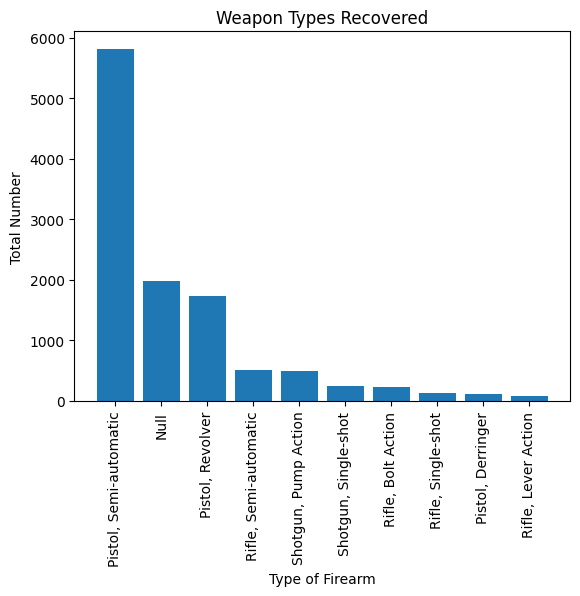

In [29]:
print(df["TYPE_OF_FIREARM"].value_counts().describe())
print(df["TYPE_OF_FIREARM"].value_counts())

type_of_firearm = df.groupby("TYPE_OF_FIREARM")["TYPE_OF_FIREARM"].value_counts().sort_values(ascending=False).head(10)
plt.bar(type_of_firearm.index, type_of_firearm.values)
plt.title("Weapon Types Recovered")
plt.xlabel("Type of Firearm")
plt.xticks(rotation=90)
plt.ylabel("Total Number")
plt.show()

"FIREARM_MANUFACTURER" is of less interest to me, since manufacturers often produce multiple types of firearms. Given the overwhelming preference for Pistols illustrated in the previous chart, the top manufacturers must inevitably produce this weapon type, so it's no surprise to see names like Smith & Wesson, Hipoint, Ruger, Glock, and Taurus in the top 5.

Note: Taurus is both the top 5 and top 6 manufacturer under different names, indicating some manufacturers should probably be renamed. Check the 459 unique manufactures for similar names, (Smith & Wesson, Smith and Wesson, S&W, etc.)

count     459.000000
mean       22.274510
std        94.559256
min         1.000000
25%         1.000000
50%         2.000000
75%         7.500000
max      1098.000000
Name: count, dtype: float64
FIREARM_MANUFACTURER
Smith & Wesson               1098
Null                          870
Hipoint                       813
Ruger                         698
Glock, Inc.                   688
                             ... 
B. H.                           1
I O Inc (inter Ordinance)       1
Feather Ind Inc                 1
Saiga                           1
Astar                           1
Name: count, Length: 459, dtype: int64


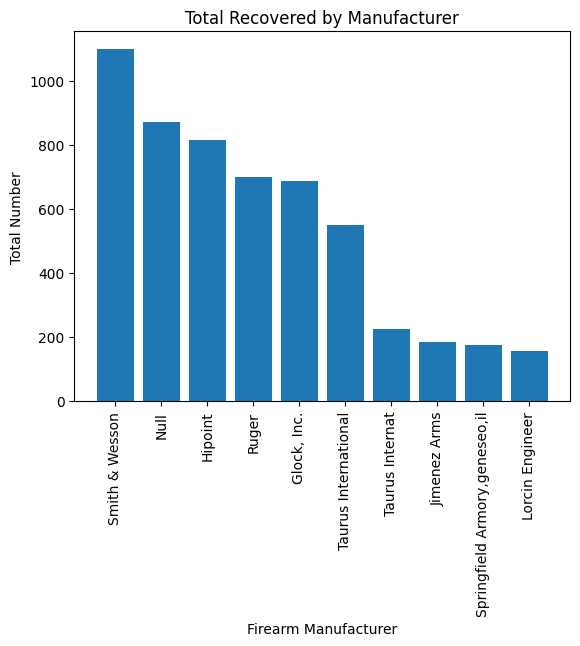

In [32]:
print(df["FIREARM_MANUFACTURER"].value_counts().describe())
print(df["FIREARM_MANUFACTURER"].value_counts())

firearm_manufacturer = df.groupby("FIREARM_MANUFACTURER")["FIREARM_MANUFACTURER"].value_counts().sort_values(ascending=False).head(10)
plt.bar(firearm_manufacturer.index, firearm_manufacturer.values)
plt.title("Total Recovered by Manufacturer")
plt.xlabel("Firearm Manufacturer")
plt.xticks(rotation=90)
plt.ylabel("Total Number")
plt.show()

There are too few instances of any single firearm model from which to draw useful inferences.

In [33]:
print(df["FIREARM_MODEL"].value_counts().describe())
print(df["FIREARM_MODEL"].value_counts())

count    1142.000000
mean        5.995622
std        28.805111
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max       870.000000
Name: count, dtype: float64
FIREARM_MODEL
Null               870
Pistol: Model X    155
Model 22/22c (4    155
Handguns: P Ser    129
Hi-point           118
                  ... 
300-399 Modles       1
Model 22             1
Special              1
622                  1
M11                  1
Name: count, Length: 1142, dtype: int64


It comes as no surprise that the most common calibers are those found primarily in pistols. Of them, 9mm is preferred with over 2200 records, followed by more than 1100 records of "40c" (.40 S&W). The only outright exceptions in the top 10 appear to be "12GA" (12 gauge, a shotgun caliber) with 707 records, and "762M" (7.62, a high-power rifle caliber) with 269 records.

count      58.000000
mean      165.068966
std       387.052418
min         1.000000
25%         3.000000
50%        15.000000
75%        64.500000
max      2215.000000
Name: count, dtype: float64
FIREARM_CALIBER
9MM     2215
40C     1104
22C     1095
380C     919
38C      826
12GA     707
45C      621
25C      350
357C     280
762M     269
32C      223
20GA     135
4570     114
556M      74
410G      66
44C       60
223C      59
50C       56
3006      51
3220      32
16GA      30
30C       29
243C      23
635M      21
765M      19
6666      19
10MM      18
270C      17
222C      15
308C      15
57        14
300C      12
7MM        9
375C       8
763M       6
204        6
54C        5
250C       5
58C        4
221C       4
8MM        4
257C       4
17C        3
338C       3
401C       3
177C       3
735M       3
6MM        2
10GA       2
41C        2
303C       2
24GA       2
36C        1
28GA       1
444C       1
35C        1
32GA       1
455C       1
Name: count, dtype: int64


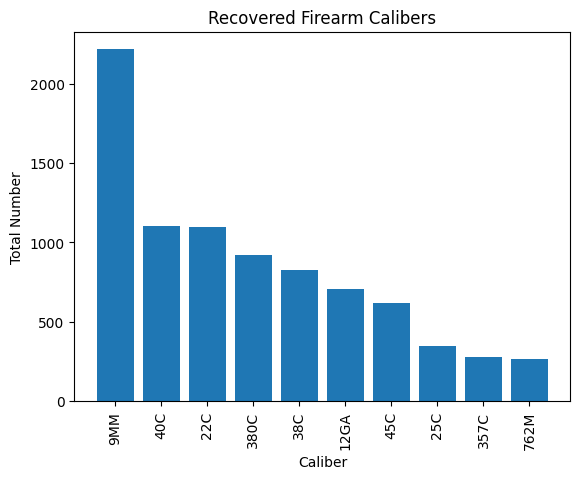

In [35]:
print(df["FIREARM_CALIBER"].value_counts().describe())
print(df["FIREARM_CALIBER"].value_counts())

firearm_caliber = df.groupby("FIREARM_CALIBER")["FIREARM_CALIBER"].value_counts().sort_values(ascending=False).head(10)
plt.bar(firearm_caliber.index, firearm_caliber.values)
plt.title("Recovered Firearm Calibers")
plt.xlabel("Caliber")
plt.xticks(rotation=90)
plt.ylabel("Total Number")
plt.show()

The "RECOVERY__ADDRESS" column describes where firearms are recovered. Of the 2672 unique addresses, 600 W Jefferson St represents more than 2400 records, while only 1 other address exceeded 100.

In [57]:
print(df["RECOVERY__ADDRESS"].value_counts().describe())
print(df["RECOVERY__ADDRESS"].value_counts())

count    2672.000000
mean        4.394461
std        50.140522
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max      2429.000000
Name: count, dtype: float64
RECOVERY__ADDRESS
600 W Jefferson St        2429
Null                       870
3700 Klondike Ln           178
800 Barret Ave              75
1500 Frankfort Ave          63
                          ... 
400 N 29 St                  1
900 Burton Ave               1
1300 Cherry Blossom Dr       1
100 Pope St                  1
3700 River Park Dr           1
Name: count, Length: 2672, dtype: int64


The "Address_Concat" column contains the same general information, but with the city and zipcode added on. A strange decision, considering separate "CITY", "state", and "RECOVERY_ZIPCODE" columns already exist.

In [54]:
print(df["Address_Concat"].value_counts())

Address_Concat
600 W Jefferson St Louisville KY 40202    2333
3700 Klondike Ln Louisville KY 40218       177
800 Barret Ave Louisville KY 40204          71
12500 Kiawah Ct Louisville KY 40245         54
1300 Huntoon Ave Louisville KY 40215        50
                                          ... 
2300 Medford Ln Louisville KY 40218          1
2600 Conestoga Ave Louisville KY 40210       1
500 Denmark St Louisville KY 40215           1
900 Burton Ave Louisville KY 40208           1
9400 National Tpke Louisville KY 40118       1
Name: count, Length: 2748, dtype: int64


The vast majority (over 11000 records) of values in the "CITY" column simply list "Louisville" as the city of recovery, with fewer than 100 records in all but one other value, "Lyndon", that either place the recovery slightly outside the Louisville city limits, or list home rule class cities and subdivisions within Louisville city limits. With so few records, meaningful analysis of such columns would be difficult.

In [56]:
print(df["CITY"].value_counts().describe())
print(df["CITY"].value_counts())

count       55.000000
mean       213.254545
std       1503.822441
min          1.000000
25%          1.000000
50%          2.000000
75%          8.500000
max      11162.000000
Name: count, dtype: float64
CITY
Louisville            11162
Lyndon                  116
Shively                  99
Jeffersontown            53
Htck                     39
Middletown               29
Wb                       24
Rolling_hills            20
Watterson_park           18
St_matthews              18
Green_spring             16
Worthington_hills        11
Hurstbourne               9
Hollyvilla                9
Mede                      8
Druid_hills               7
Douglass_hills            7
Hurstbourne_acres         7
Lynd                      6
Shv                       6
New Albany                6
Lynnview                  5
West_buechel              4
Strathmoor_village        3
Moorland                  3
Brownsboro_village        3
Prospect                  2
Poplar_hills              2
Unk    

Practically all firearms were recovered in Kentucky. No other useful information can be discerned from the "state" column.

In [59]:
print(df["state"].value_counts().describe())
print(df["state"].value_counts())

count        2.000000
mean      5870.000000
std       8291.534116
min          7.000000
25%       2938.500000
50%       5870.000000
75%       8801.500000
max      11733.000000
Name: count, dtype: float64
state
KY    11733
IN        7
Name: count, dtype: int64


The "RECOVERY_ZIPCODE" column shows 40202 is the highest represented area, which is unsurprising considering this is the zipcode of the most common recovery address, 600 W Jefferson St. Notably, the other 9 top recovery zipcodes range between approximately 500 to 800 records, which shows that, even if we were to group cities in the "CITY" column by their zipcodes, this area is the most dangerous among them by far, with more than 3 times as many recovered firearms than the next highest value count.

count      41.000000
mean      286.390244
std       433.555295
min         1.000000
25%        51.000000
50%       167.000000
75%       437.000000
max      2622.000000
Name: count, dtype: float64
RECOVERY_ZIPCODE
40202.0    2622
40211.0     774
40218.0     628
40203.0     620
40215.0     568
40212.0     556
40219.0     542
40214.0     535
40210.0     525
40216.0     510
40272.0     437
40258.0     371
40208.0     280
40206.0     254
40213.0     240
40204.0     236
40291.0     224
40229.0     201
40220.0     175
nan         171
40217.0     167
40299.0     161
40241.0     149
40118.0     146
40222.0     108
40245.0      98
40228.0      93
40205.0      76
40223.0      60
40242.0      52
40243.0      51
40207.0      48
40209.0      42
40059.0       9
40023.0       6
40165.0       2
40056.0       1
42259.0       1
47130.0       1
40177.0       1
40058.0       1
Name: count, dtype: int64


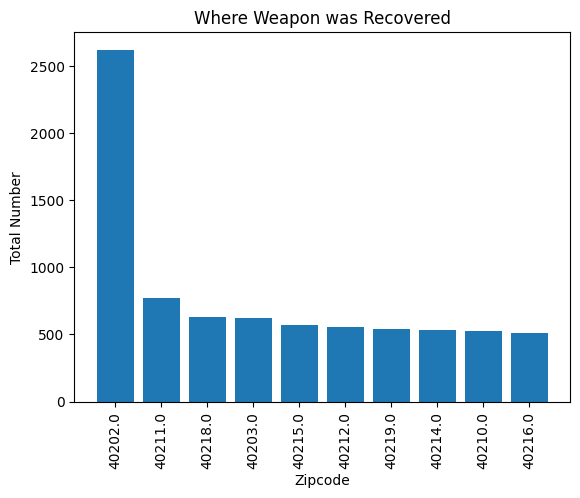

In [58]:
new_df = df
new_df["RECOVERY_ZIPCODE"] = df["RECOVERY_ZIPCODE"].astype(str)

print(new_df["RECOVERY_ZIPCODE"].value_counts().describe())
print(new_df["RECOVERY_ZIPCODE"].value_counts())

recovery_zipcode = new_df.groupby("RECOVERY_ZIPCODE")["RECOVERY_ZIPCODE"].value_counts().sort_values(ascending=False).head(10)
plt.bar(recovery_zipcode.index, recovery_zipcode.values)
plt.title("Where Weapon was Recovered")
plt.xlabel("Zipcode")
plt.xticks(rotation=90)
plt.ylabel("Total Number")
plt.show()

Of the racial groups from which firearms are recovered, Blacks represent nearly 5200 records, and Whites nearly 3800. If we dismiss the nearly 2500 NULL records, and group the remaining racial groups into an "Other" category, then approximately 56% of recorded firearms were recovered from Blacks, 41% from Whites, and the remaining 3% from Other.

count       9.000000
mean     1304.666667
std      1992.944304
min         4.000000
25%         8.000000
50%        88.000000
75%      2482.000000
max      5161.000000
Name: count, dtype: float64
PERSON_RECOVERED_FROM_RACE
Black                   5161
White                   3775
Null                    2482
Hispanic                 197
Unknown                   88
Asian                     22
American Indian            8
Middle Eastern             5
Indian/india/burmese       4
Name: count, dtype: int64


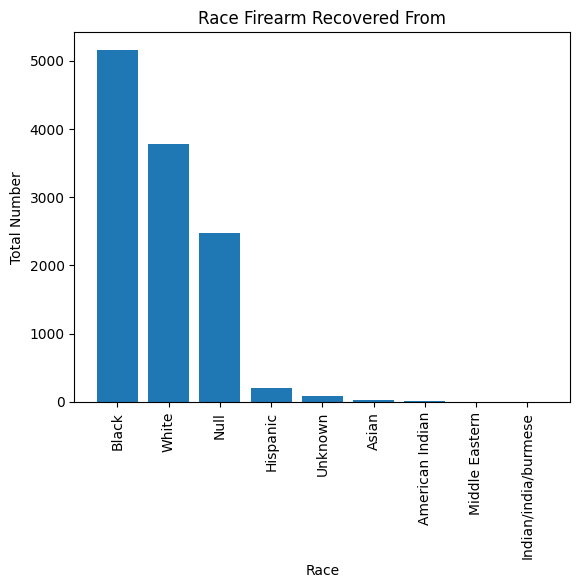

In [61]:
print(df["PERSON_RECOVERED_FROM_RACE"].value_counts().describe())
print(df["PERSON_RECOVERED_FROM_RACE"].value_counts())

person_recovered_from_race = df.groupby("PERSON_RECOVERED_FROM_RACE")["PERSON_RECOVERED_FROM_RACE"].value_counts().sort_values(ascending=False)
plt.bar(person_recovered_from_race.index, person_recovered_from_race.values)
plt.title("Race Firearm Recovered From")
plt.xlabel("Race")
plt.xticks(rotation=90)
plt.ylabel("Total Number")
plt.show()

The data shows firearms are much more likely to be recovered from men than women, at a ratio exceeding 9 to 1.

count       3.000000
mean     3096.666667
std      4682.886325
min        75.000000
25%       399.500000
50%       724.000000
75%      4607.500000
max      8491.000000
Name: count, dtype: float64
PERSON_RECOVERED_FROM_SEX
M    8491
F     724
U      75
Name: count, dtype: int64


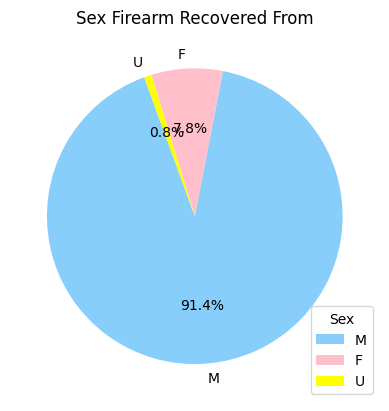

In [ ]:
sex = df["PERSON_RECOVERED_FROM_SEX"].value_counts()
print(sex.describe())
print(sex)


plt.pie(
    sex,
    labels = sex.index,
    startangle=110,
    colors=["lightskyblue", "pink", "yellow", "brown"],
    autopct="%1.1f%%")

plt.title("Sex Firearm Recovered From")
plt.legend(
    labels = sex.index,
    loc="lower right",
    title = "Sex"
)

count     73.000000
mean     123.520548
std      130.698562
min        1.000000
25%       12.000000
50%       73.000000
75%      201.000000
max      435.000000
Name: count, dtype: float64
PERSON_RECOVERED_FROM_AGE
25.0    435
23.0    420
22.0    397
20.0    397
18.0    388
       ... 
0.0       2
69.0      2
76.0      1
80.0      1
9.0       1
Name: count, Length: 73, dtype: int64


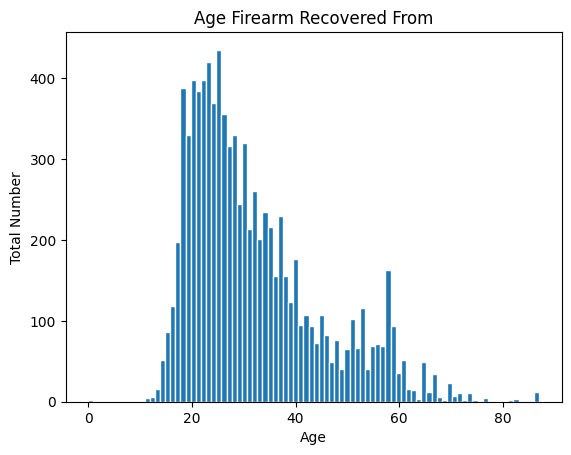

In [279]:
print(df["PERSON_RECOVERED_FROM_AGE"].value_counts().describe())
print(df["PERSON_RECOVERED_FROM_AGE"].value_counts())

#age = df.groupby("PERSON_RECOVERED_FROM_AGE")["PERSON_RECOVERED_FROM_AGE"].value_counts().sort_values(ascending=False)
#plt.bar(age.index, age.values)
plt.hist(df["PERSON_RECOVERED_FROM_AGE"], bins=88, edgecolor="white")

plt.title("Age Firearm Recovered From")
plt.xlabel("Age")
plt.ylabel("Total Number")
plt.show()

count      10.000000
mean     1482.900000
std       982.831448
min         3.000000
25%       805.500000
50%      1777.500000
75%      1965.000000
max      2952.000000
Name: count, dtype: float64
year
2016.0    2952
2015.0    2274
2014.0    1989
2011.0    1893
2013.0    1822
2012.0    1733
2010.0    1629
2017.0     531
2009.0       3
2008.0       3
Name: count, dtype: int64


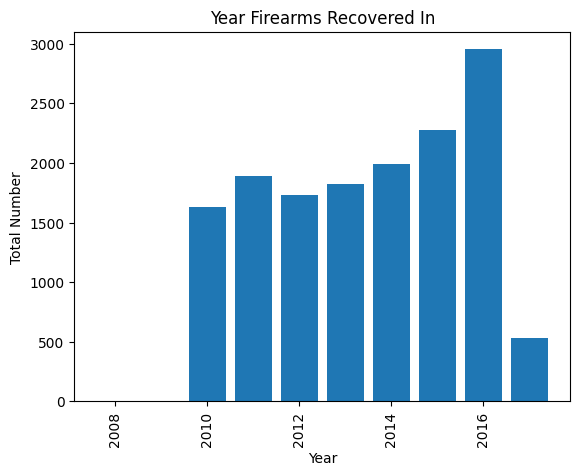

In [ ]:
# print(df["year"].value_counts().describe())
# print(df["year"].value_counts())

# df_years = df.groupby("year")["year"].value_counts().sort_values(ascending=False)
# plt.bar(df_years.index, df_years.values)
# plt.title("Year Firearms Recovered In")
# plt.xlabel("Year")
# plt.xticks(rotation=90)
# plt.ylabel("Total Number")
# plt.show()